In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import KFold, cross_validate

In [39]:
#!pip install gdown
#!gdown 12G_J8gBel8MpspdXJruZuuMvyrm9upNb
#!gdown 1-zjfYbZm8JC4wog9tG4zltMPuZM6p9_A

#!gdown 1p03Ltdto8XoOdu14YlcQjzE-360SyI89
#!gdown 1mNcWfaEW19ql8WCih6HiqRryCcjFUUqx

In [40]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [41]:
X_train.head()

,Age,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,36,1174,3,4,0.233871,1,0,99,3,2,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,21,546,5,1,0.127479,3,1,97,3,1,...,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,43,422,1,3,0.151584,4,0,33,3,2,...,2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,42,188,29,3,0.127479,2,1,56,1,2,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,35,992,1,3,0.127479,4,1,68,2,1,...,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [42]:
y_train.head()

,Target
0,0
1,0
2,0
3,0
4,0


In [43]:
y_train.Target.value_counts(normalize=True)

Target
0    0.838475
1    0.161525
Name: proportion, dtype: float64

In [44]:
smt = SMOTE()
X_sm, y_sm = smt.fit_resample(X_train, y_train)
print(y_sm.value_counts(normalize=True))

Target
0         0.5
1         0.5
Name: proportion, dtype: float64


In [45]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_sm, y_sm)

DecisionTreeClassifier()

In [46]:
tree_clf.score(X_sm,y_sm)

1.0

In [47]:
tree_clf.score(X_test,y_test)

0.7907608695652174

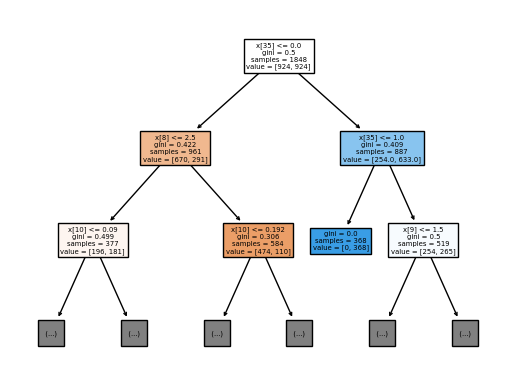

In [48]:
plot_tree(tree_clf, filled=True, max_depth=2)
plt.show()

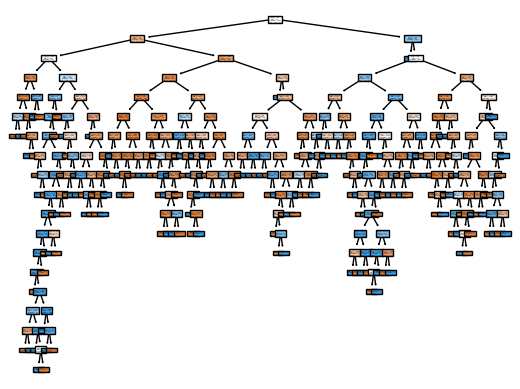

In [49]:
plot_tree(tree_clf, filled=True)
plt.show()

In [50]:
tree_clf.tree_.max_depth

18

In [51]:
depths = [3,4,5,6,7,9,11,13,15, 16]
kfold = 10
for depth in depths:
    tree_clf = DecisionTreeClassifier(random_state=42, max_depth = depth)

    cv_acc_results = cross_validate(tree_clf, X_sm, y_sm, cv = kfold, scoring = 'f1', return_train_score = True)

    print(f"K-Fold for depth:{depth} Accuracy Mean: Train: {cv_acc_results['train_score'].mean()*100} Validation: {cv_acc_results['test_score'].mean()*100}")
    print("-="*20)

K-Fold for depth:3 Accuracy Mean: Train: 78.47335018831633 Validation: 76.59410993717094
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:4 Accuracy Mean: Train: 80.6115919565518 Validation: 77.47445834357752
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:5 Accuracy Mean: Train: 85.46618189417788 Validation: 78.3654643592457
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:6 Accuracy Mean: Train: 89.01180065982611 Validation: 80.07661050034096
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:7 Accuracy Mean: Train: 92.87347506365677 Validation: 81.87975805075233
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:9 Accuracy Mean: Train: 97.59293532447563 Validation: 82.89180578139043
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:11 Accuracy Mean: Train: 99.3645232748744 Validation: 82.02036462267301
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:13 Accuracy Mean: Train: 99.82598408012879 Validation: 82.02454032012841
-=

In [52]:
tree_clf = DecisionTreeClassifier(max_depth = 5)
tree_clf.fit(X_sm, y_sm)

DecisionTreeClassifier(max_depth=5)

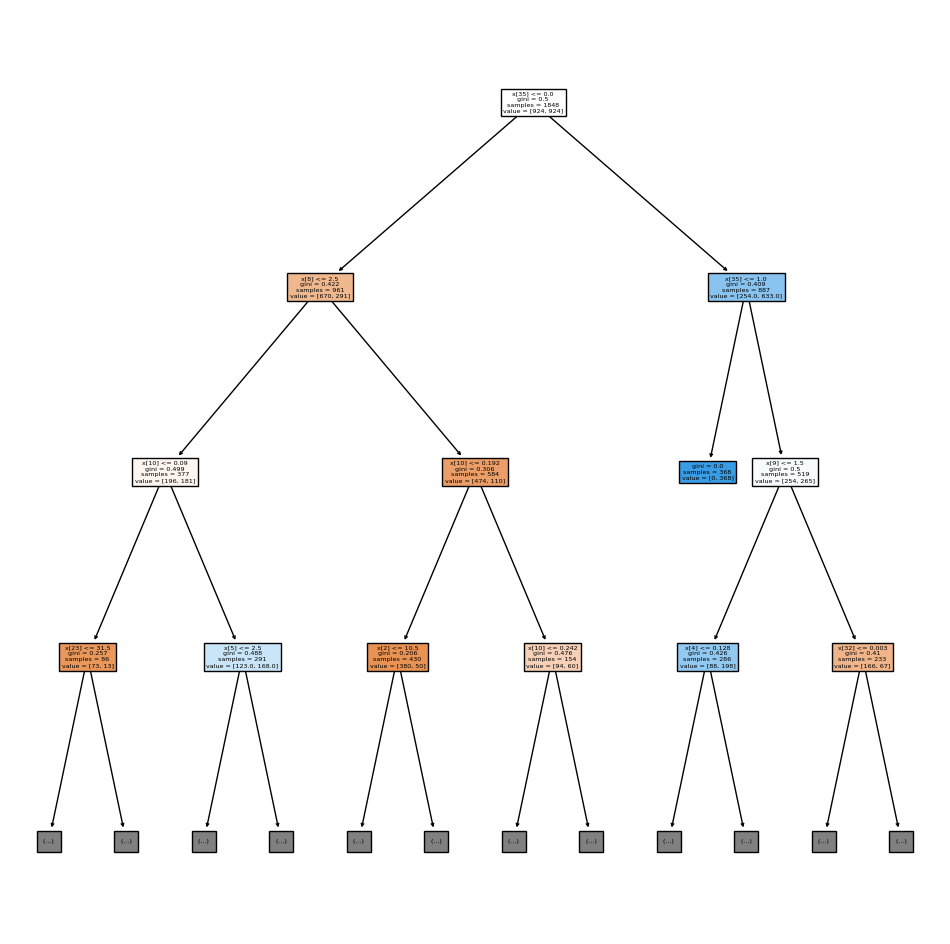

In [53]:
plt.figure(figsize = (12, 12))
plot_tree(tree_clf, filled=True, max_depth = 3)
plt.show()

In [54]:
tree_clf.feature_importances_

array([0.        , 0.        , 0.00984988, 0.        , 0.03569615,
       0.02997167, 0.00585353, 0.        , 0.07338113, 0.0791533 ,
       0.10227544, 0.01807347, 0.03843203, 0.00561075, 0.00386822,
       0.        , 0.        , 0.        , 0.        , 0.01887538,
       0.        , 0.02664531, 0.        , 0.01485196, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.05043464, 0.        , 0.        ,
       0.48702713])